### Keras Neural Network

https://keras.io/examples/

2024-08-11 13:16:41.769940: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-08-11 13:16:41.772535: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-08-11 13:16:41.779745: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-11 13:16:41.790768: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-11 13:16:41.793947: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-11 13:16:41.803966: I tensorflow/core/platform/cpu_feature_gu

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,506 (5.89 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,005 (3.93 KB)

Mean absolute error=0.545


Text(0, 0.5, 'Distance (m)')

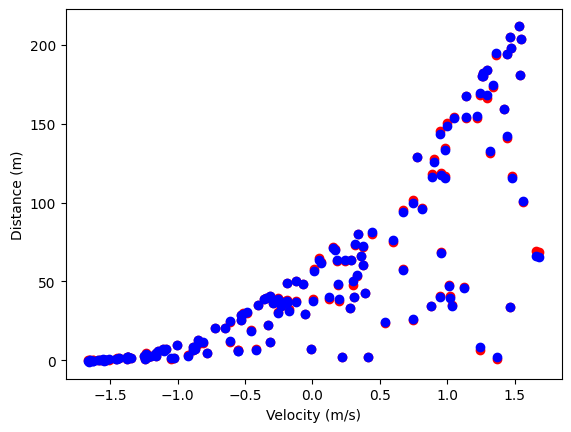

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

import keras
from keras import layers

X = np.load('data_X.npy')
Y = np.load('data_Y.npy')
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = keras.Sequential()
model.add(keras.Input(shape=(2,)))
model.add(layers.Dense(20, activation='relu', kernel_initializer='he_normal'))
model.add(layers.Dense(20, activation='relu', kernel_initializer='he_normal'))
model.add(layers.Dense(1, activation='linear',  kernel_initializer='he_normal'))
model.compile(optimizer='nadam', loss='mse', metrics=['mean_absolute_error'])
model.fit(X_train, y_train, epochs=3000, batch_size=50, verbose=0)
model.summary()

predictions = model.predict(X_test, verbose=0)
print(f"Mean absolute error={mean_absolute_error(y_test, predictions):.3f}")

plt.scatter(X_test[:,1], y_test, c='r')
plt.scatter(X_test[:,1], predictions, c='b')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Distance (m)')